# Uncalibrated risk calculations

This notebook will walk through the a risk calculation in CLIMADA with the uncalibrated data.

It will read in data, create the CLIMADA objects needed for the analysis, run the risk calculation, and explore the outputs including plots and statistics.

This analysis is being performed with the _uncalibrated_ Entity files containing our first guess impact functions. Therefore the purpose of this notebook is also to notice the shortcomings of the analysis and identify how it has to be improved.

In [1]:
from pathlib import Path

# Set up paths to data
ENTITY_DIR = "../data/entity_files_uncalibrated/"
ENTITY_FILES = {
    "maize": "El_Salvador_Entity_Drought_Maize.xlsx",
    "beans": "El_Salvador_Entity_Drought_Beans.xlsx",
    "sorghum": "El_Salvador_Entity_Drought_Sorghum.xlsx"
}
entity_filepaths = {crop: Path(ENTITY_DIR) / filename for crop, filename in ENTITY_FILES.items()}

# Set up paths to hazard data (different crops experience different hazards)
HAZARD_DIR = "../data/hazard/annual/"
HAZARD_FILES = {
    "maize": "ElSalvador_SPEI12_present_maize.tif",
    "beans": "ElSalvador_SPEI12_present_beans.tif",
    "sorghum": "ElSalvador_SPEI12_present_sorghum.tif",
}
haz_filepaths = {crop: Path(HAZARD_DIR) / filename for crop, filename in HAZARD_FILES.items()}

## Read in data

### Entity files

In [2]:
import copy
from climada.entity import Entity

# Read the Entity file and set additional metadata for the Exposures
entity_dict = {}
for crop, filepath in entity_filepaths.items():
    print(f"Reading {filepath.name}...")
    entity = Entity.from_excel(filepath)
    entity.exposures.ref_year = 2023
    entity.exposures.value_unit = "kg"
    entity.exposures.description = f"Annual production: {crop} ({entity.exposures.value_unit})"
    entity_dict[crop] = copy.deepcopy(entity)
    print(f"Read Entity with {len(entity.exposures.gdf)} exposure points")

Reading El_Salvador_Entity_Drought_Maize.xlsx...
Read Entity with 14 exposure points
Reading El_Salvador_Entity_Drought_Beans.xlsx...
Read Entity with 14 exposure points
Reading El_Salvador_Entity_Drought_Sorghum.xlsx...
Read Entity with 14 exposure points


### Plot exposures

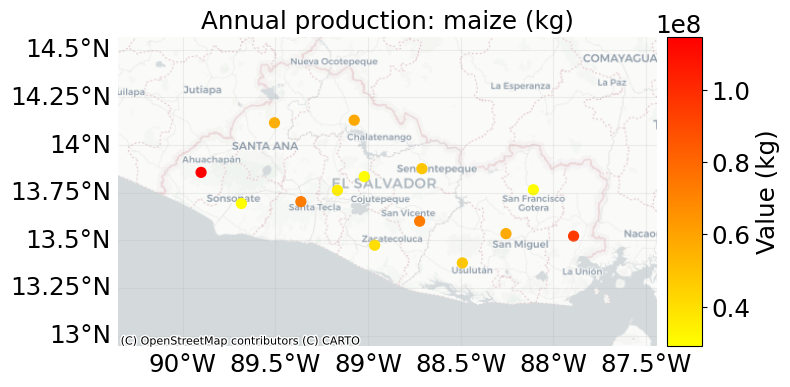

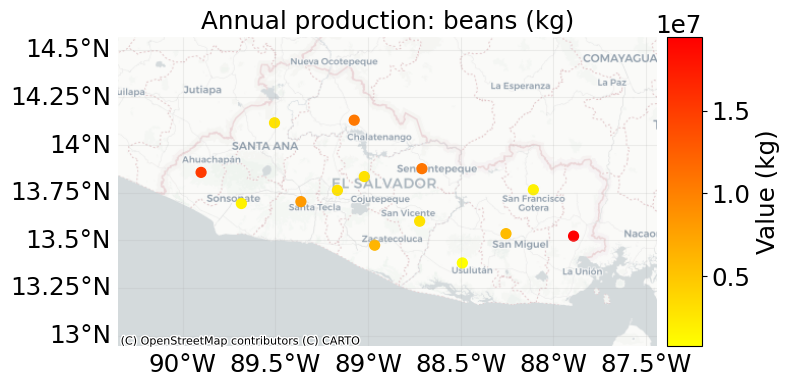

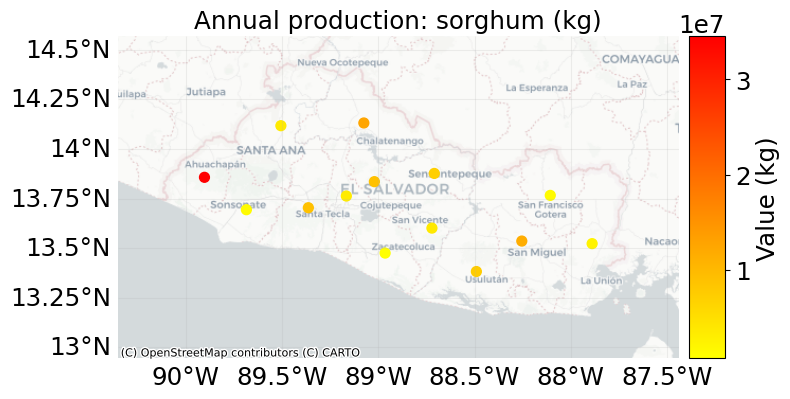

In [3]:
%matplotlib inline
for crop, entity in entity_dict.items():
    entity.exposures.plot_basemap(
        title=f"Annual production: {crop} ({entity.exposures.value_unit})",
        ignore_zero=True,        # Whether to plot points with zero value
        buffer=50000,            # Add a buffer around the points to show a larger map region (measured in meters)
        s=50,                    # The size of point markers on the plot
        zoom=8,                  # The detail level of the map. 6 is good for a large country. 8 is good for a state or region. 13 for a city. 15 for a municipality.
        pop_name=False,          # Add the names of populated places to the map – often not necessary when you have a basemap
        vmax=None,               # Set the maximum value for the colour scale – use this if you want a consistent scheme across multiple plots.
        cmap="autumn_r",         # Colour scheme to use for the points. See https://matplotlib.org/stable/tutorials/colors/colormaps.html for options.
        figsize=(8, 10)          # Dimensions of the output figure
    )

### Plot uncalibrated impact functions

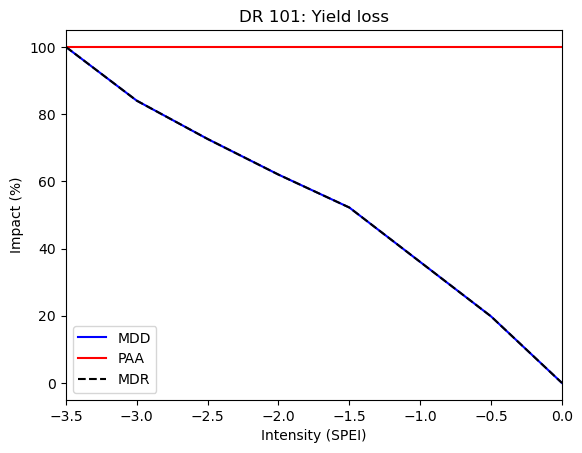

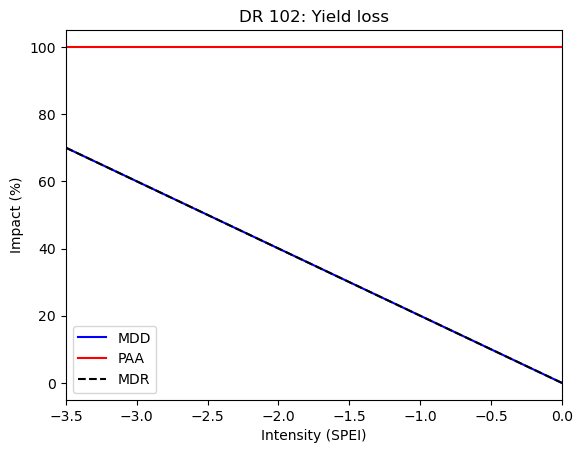

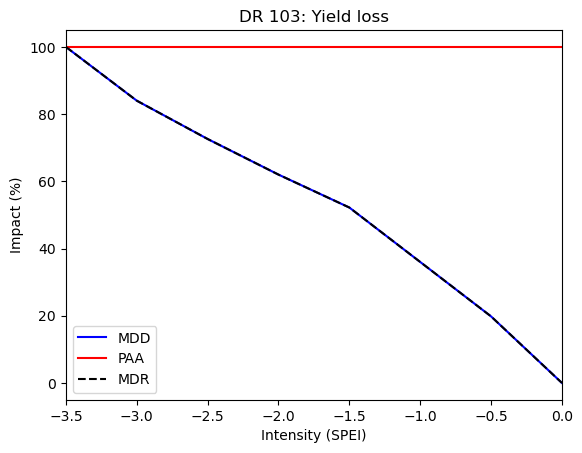

In [4]:
for entity in entity_dict.values():
    entity.impact_funcs.plot()

### Hazard

The hazard data comes from simulated SPEI data for recent decades. Note that this is note a reconstruction: while the hazard data has droughts, they will not necessarily occur in the same years as historical observations.

In [5]:
import copy
import numpy as np
from climada.hazard import Hazard

n_years_data = 54   # 1972 to 2025 inclusive
event_frequency = 1 / n_years_data   

# Read in the hazard data
haz_dict = {}

for crop, filepath in haz_filepaths.items():
    haz = Hazard.from_raster(
        files_intensity = filepath,
        band=list(np.arange(n_years_data) + 1),
        attrs={
            'unit': 'SPEI',   # as an index the SPEI has no units – so we can specify this or an empty string, as long as it is consistent with the Entity file Impact Functions
            'event_name': [str(year) for year in np.arange(1972, 2026)],     # We can optionally name the events
            'frequency': np.full(n_years_data, event_frequency)              # Define the frequency of each event
        },
        haz_type='DR',        # Specify that this is drought data
        window=None,          # Only read a window from the raster datasets, provided as a rasterio.windows.Windows object 
        geometry=None,        # Only read within a given geometry, provided as a list of shapely.geometry objects
    )

    haz.intensity[haz.intensity > 0] = 0     # Set positive drought indices to zero to speed up calculation 
    haz_dict[crop] = copy.deepcopy(haz)


2026-07-07 00:20:14,260 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_maize.tif
2026-07-07 00:20:14,271 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_maize.tif
2026-07-07 00:20:14,276 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_beans.tif
2026-07-07 00:20:14,281 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_beans.tif
2026-07-07 00:20:14,285 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_sorghum.tif
2026-07-07 00:20:14,292 - climada.util.coordinates - INFO - Reading ../data/hazard/annual/ElSalvador_SPEI12_present_sorghum.tif


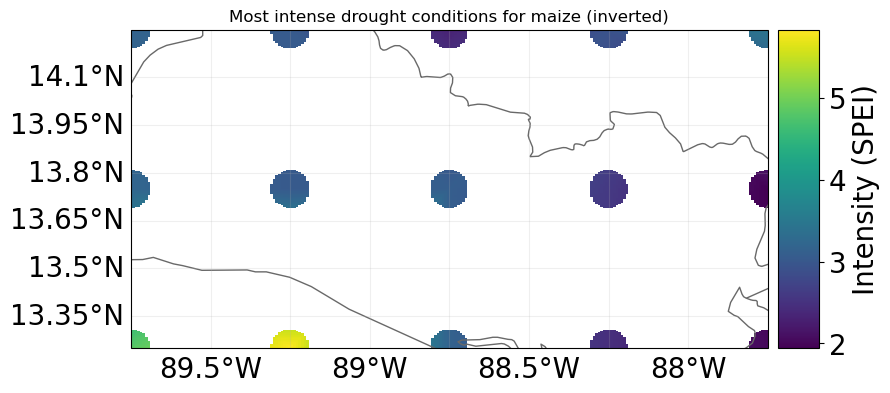

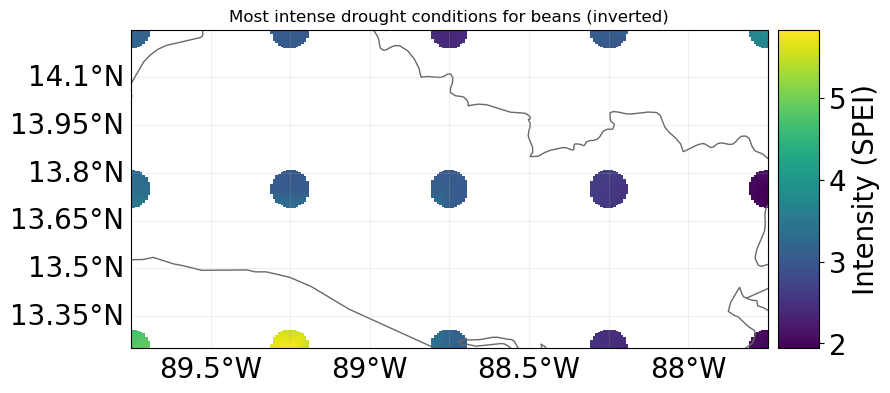

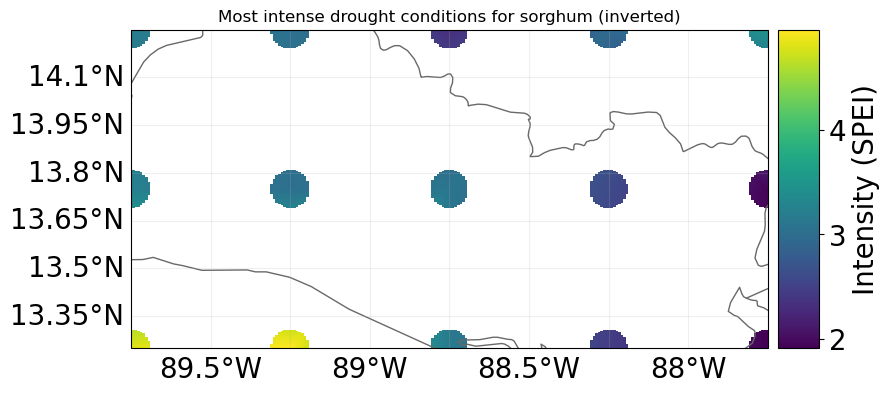

In [6]:
# Plot most intense values from all events
# As in the Hazard notebook, for the plot we multiply the SPEI by -1 so that larger positive values are more intense
for crop, haz in haz_dict.items():
    haz_inverted = copy.deepcopy(haz)
    haz_inverted.intensity = -haz.intensity
    axis = haz_inverted.plot_intensity(event=0)
    _ = axis.set_title(f"Most intense drought conditions for {crop} (inverted)")

### Map Hazard centroids to Exposure points

When CLIMADA is given a hazard and an exposure dataset it has to infer the intensity of the hazard at every exposure point. Often the hazard centroids and the exposure locations do not line up exactly. In these cases, CLIMADA finds the closest hazard centroid for each exposure, within a certain maximum search distance, set by a `threshold` parameter (or estimated by the model if not provided).

The hazard in this dataset is on a regular grid, and so CLIMADA is able to choose a distance threshold and map to the nearest centroids without difficulty.

In [7]:
for crop in entity_dict.keys():
    ent = entity_dict[crop]
    haz = haz_dict[crop]
    ent.exposures.assign_centroids(hazard=haz, overwrite=True)


2026-07-07 00:20:18,122 - climada.entity.exposures.base - INFO - Matching 14 exposures with 15 centroids.
2026-07-07 00:20:18,130 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 1.0 degree
2026-07-07 00:20:18,162 - climada.entity.exposures.base - INFO - Matching 14 exposures with 15 centroids.
2026-07-07 00:20:18,169 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 1.0 degree
2026-07-07 00:20:18,180 - climada.entity.exposures.base - INFO - Matching 14 exposures with 15 centroids.
2026-07-07 00:20:18,185 - climada.util.coordinates - INFO - No exact centroid match found. Reprojecting coordinates to nearest neighbor closer than the threshold = 1.0 degree


## Calculate risk

With all these ingredients we can run risk calculations using CLIMADA's `ImpactCalc` class.

The following sections run the calculations and visualize them. The first-guess outputs have shortcomings that are discussed at the end of the notebook, and which will be used to guide the calibrations.

In [8]:
from climada.engine import ImpactCalc, ImpactFreqCurve

impacts_dict = {}

for crop in entity_dict.keys():
    ent = entity_dict[crop]
    haz = haz_dict[crop]
    
    # The ImpactCalc class sets up the calculation
    imp_calc = ImpactCalc(
        exposures=ent.exposures,
        impfset=ent.impact_funcs,
        hazard=haz
    )
    # ...and its .impact method runs the calculation, creating an Impact object
    imp = imp_calc.impact(
        save_mat=True,          # Save the impact matrix (see below). This can be large, but we want it to explore some additional calculations 
        assign_centroids=False  # Don't (re)assign centroids
    )
    impacts_dict[crop] = copy.deepcopy(imp)

2026-07-07 00:20:18,246 - climada.engine.impact_calc - INFO - Calculating impact for 70 assets (>0) and 54 events.
2026-07-07 00:20:18,255 - climada.engine.impact_calc - INFO - Calculating impact for 70 assets (>0) and 54 events.
2026-07-07 00:20:18,265 - climada.engine.impact_calc - INFO - Calculating impact for 70 assets (>0) and 54 events.


The Impact object has properties and methods that support you in creating risk statistics.

At the core of it is the impact matrix, which is a sparse matrix with dimensions (number of events) x (number of exposure points). It gives the calculated impact of each event at each point of exposure.

We explore this:

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

for crop, imp in impacts_dict.items():
    print(f"\nImpacts for {crop}:")
    print(f"Number of exposures: {len(imp.eai_exp)}")
    print(f"Number of events: {len(imp.event_id)}")
    print(f"Size of impact matrix: {imp.imp_mat.shape}")

    # Summing the impact across all exposed points gives us the total impact per event. This is calculated during the impact calculation and stored in the `.at_event` attribute.
    print("Total impact per event:")
    print([f'{event_name}: {impact:,.0f}' for event_name, impact in zip(imp.event_name, imp.at_event)])

    # Combining the event-wise impacts with the events' frequencies let us calculate the average annual loss (AAL). This is stored in the `.aal_agg` attribute.
    print(f"Average annual impact/loss per event: {imp.aai_agg:.0f}")



Impacts for maize:
Number of exposures: 14
Number of events: 54
Size of impact matrix: (54, 14)
Total impact per event:
['1972: 79,283,075', '1973: 135,194,513', '1974: 162,450,732', '1975: 222,956,856', '1976: 321,380,924', '1977: 352,664,421', '1978: 202,887,747', '1979: 2,665,584', '1980: 28,137,507', '1981: 353,461,779', '1982: 103,830,466', '1983: 106,358,951', '1984: 17,332,197', '1985: 212,567,888', '1986: 256,824,801', '1987: 390,571,962', '1988: 249,073,617', '1989: 157,652,993', '1990: 274,898,970', '1991: 82,827,127', '1992: 0', '1993: 0', '1994: 32,617,210', '1995: 5,324,946', '1996: 348,277,465', '1997: 366,973,191', '1998: 474,528,996', '1999: 97,383,204', '2000: 421,609,073', '2001: 72,434,805', '2002: 325,517,947', '2003: 451,887,691', '2004: 213,813,516', '2005: 408,090,693', '2006: 404,691,706', '2007: 424,441,132', '2008: 443,865,510', '2009: 280,339,863', '2010: 182,677,184', '2011: 320,007,835', '2012: 203,779,451', '2013: 283,243,235', '2014: 444,117,637', '2015:

## Plot simulated losses and exceedance

We can plot the losses simulated for each year 

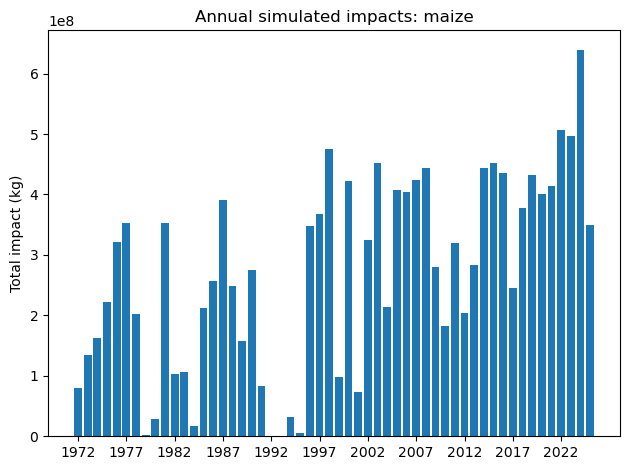

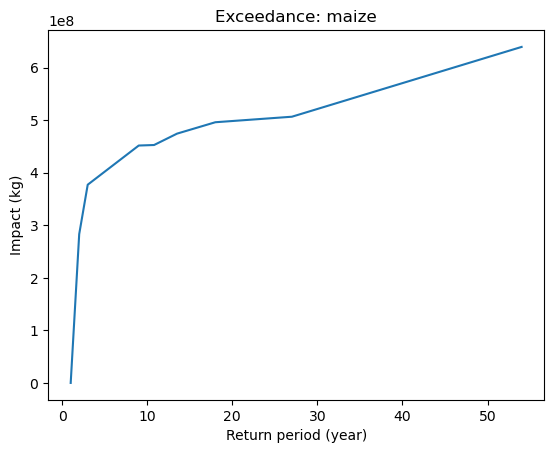

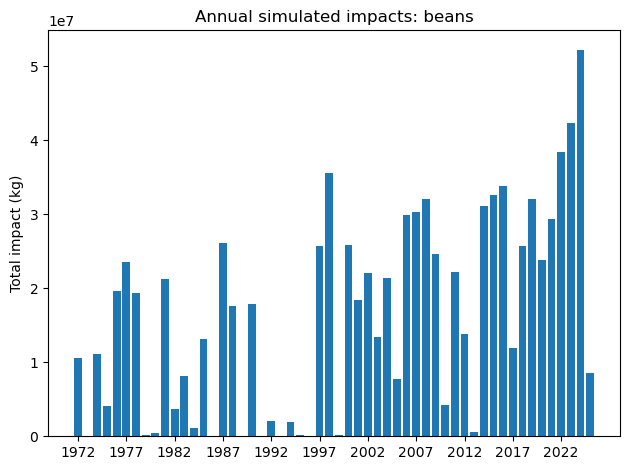

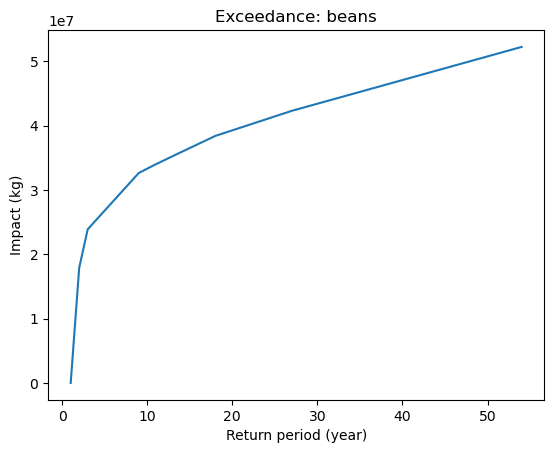

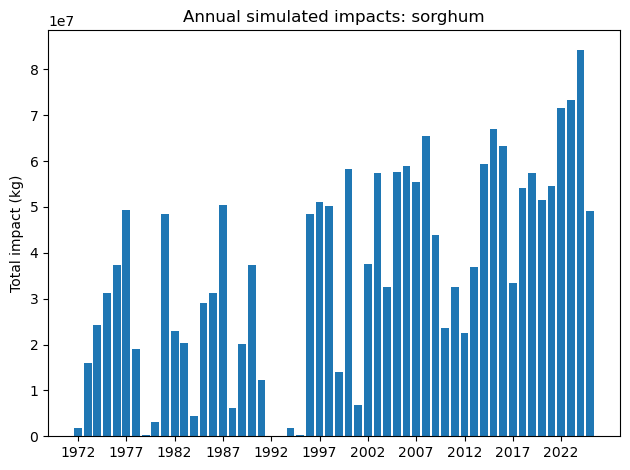

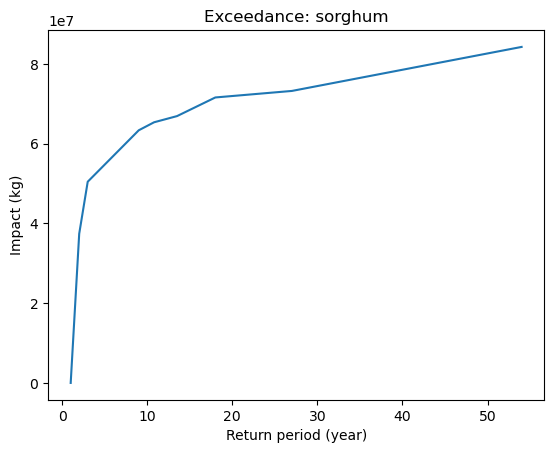

In [10]:
for crop, imp in impacts_dict.items():
    
    # Plot array of event losses as a bar chart
    plt.bar(imp.event_name, imp.at_event)
    plt.ylabel(f"Total impact ({imp.unit})")
    plt.title(f"Annual simulated impacts: {crop}")
    plt.xticks(ticks=range(0, len(imp.event_name), 5))
    plt.tight_layout()
    plt.show()

    # We can extract an exceedance curve, showing how total losses change with return periods
    # This method returns a ImpactFreqCurve object, which can be plotted.
    exceedance_curve = imp.calc_freq_curve(return_per=[1, 2, 3, 54/6, 54/5, 54/4, 54/3, 54/2, 54])   # Specify the return periods we want to see
    axis = exceedance_curve.plot()
    axis.set_title(f"Exceedance: {crop}")
    plt.show()


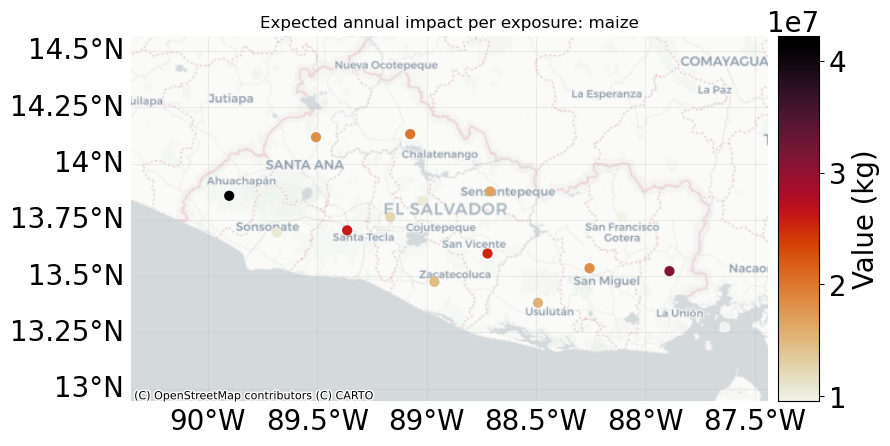

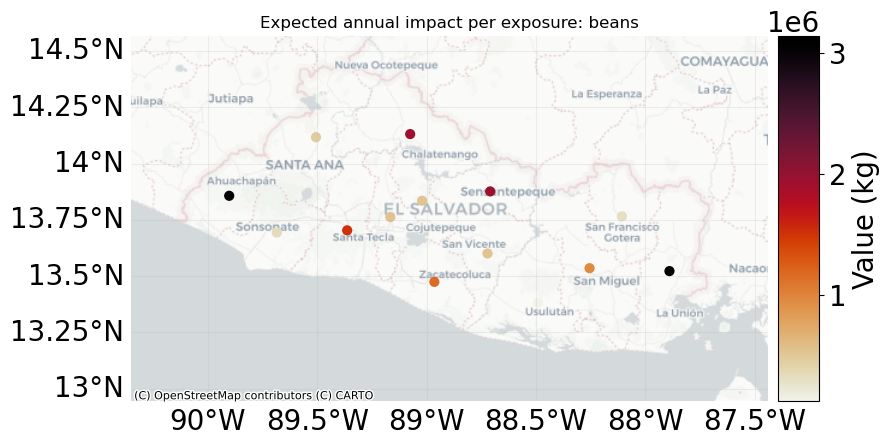

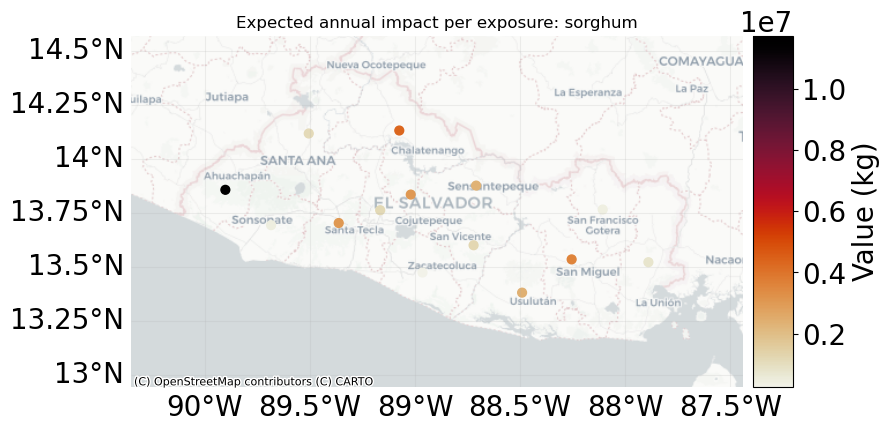

In [11]:
import contextily as ctx

# We can map the average annual impact by individual exposure point:
for crop, imp in impacts_dict.items():
    axis = imp.plot_basemap_eai_exposure(
        ignore_zero=True,                   # Don't plot locations with zero impacts
        pop_name=False,                     # Don't plot place names
        buffer=50000,                       # Add spatial buffers to the map (in the CRS coordinate units)
        s=40,                               # The size of point markers on the plot
        zoom=8,                             # Level of detail to add to the basemap
        url=ctx.providers.CartoDB.Positron  # Basemap provider
    )
    axis.set_title(f"Expected annual impact per exposure: {crop}")


2026-07-07 00:28:42,089 - climada.engine.impact - INFO - Computing exceedance impact map for return periods: [10, 20, 50]
Exposure level return period exceedance:


,geometry,10,20,50
0,POINT (-89.90196 13.85751),8.067158e+07,9.368764e+07,1.031985e+08
1,POINT (-88.70886 13.87704),2.906687e+07,2.957569e+07,4.055981e+07
2,POINT (-89.07457 14.13120),3.751947e+07,4.120625e+07,4.889992e+07
3,POINT (-89.01998 13.83557),1.849256e+07,2.015595e+07,2.446105e+07
4,POINT (-89.36268 13.70412),4.594824e+07,5.008127e+07,6.077808e+07


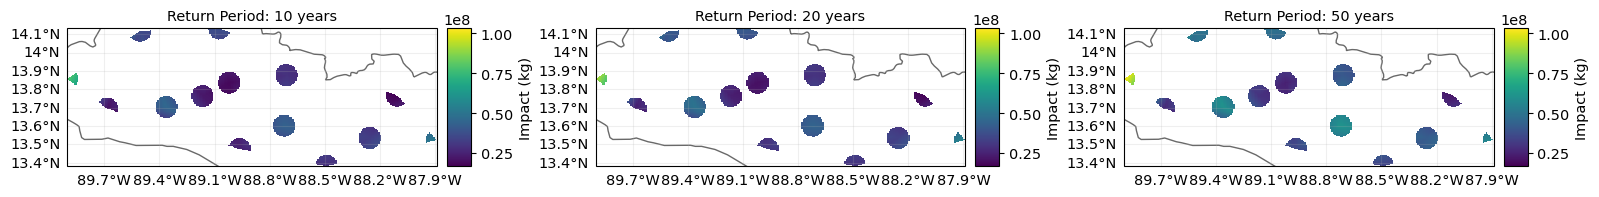

In [13]:
from IPython.display import display
from climada.util.plot import plot_from_gdf

# Looking at the impact data across all events gives us the information about the impact per exposed point instead.
# Here we look at the results for maize
imp = impacts_dict["maize"]   # Change this to look at the other crops

# Generate a GeoDataFrame of custom return period impacts for every exposure:
custom_return_periods = [10, 20, 50]
local_exceedance, label, col_label = imp.local_exceedance_impact(
    return_periods=custom_return_periods,
    method="interpolate",    # How to deal with interpolated and extrapolated impacts (default here is only interpolate)
    min_impact=0,            # Filter impacts below this value
    log_frequency=True,     
    log_impact=True,
)
local_exceedance = local_exceedance.dropna()

print("Exposure level return period exceedance:")
display(local_exceedance.head())

# Plot impacts at custom return periods
# Note that CLIMADA interpolates between points, often giving hard-to-read plots
# In CLIMADA 6.1 and higher, set mask_distance to reduce this interpolation.
_ = plot_from_gdf(
    local_exceedance,
    colorbar_name=label,
    title_subplots=col_label,
    figsize=(16, 6)
)

### Discussion

We can observe a few things from these uncalibrated losses that can guide the calibration.

- From the bar chart showing year-by-year losses it's clear that these annual impacts are too high: the default impact functions are creating significant losses _almost every year_, whereas we want to capture losses from more extreme droughts. We will probably need to adjust the impact curves so that losses at small SPEI values are not as high.
- As a consequence of this the return-period curves have large values at very low return periods: i.e. there are significant losses every one or two years. We probably want to calibrate to keep losses below 5-10 year return periods low, which is more in line with historical droughts.
- The last plot, showing point losses at different return periods, all look very similar, again because the 10-year losses are already large. We will want to calibrate so that there are more extreme events, i.e. to create a more noticeable difference between 10-year and 50-year losses.